In [1]:
import os
import jax
import zodiax as zdx
from zodiax.optimisation import sgd, adam
from jax import numpy as np, random as jr

jax.config.update("jax_enable_x64", True)

import amigo
import dorito
import astropy

# from optim_funcs import sgd, adam

# visualisation
import matplotlib.pyplot as plt
import matplotlib as mpl
import ehtplot
import scienceplots
import cmasher as cmr

# matplotlib parameters
plt.style.use(["science", "bright", "no-latex"])

plt.rcParams["image.cmap"] = "inferno"
plt.rcParams["font.family"] = "serif"
plt.rcParams["image.origin"] = "lower"
plt.rcParams["figure.dpi"] = 300
plt.rcParams["font.size"] = 8
plt.rcParams["xtick.direction"] = "out"
plt.rcParams["ytick.direction"] = "out"

inferno = mpl.colormaps["inferno"]
viridis = mpl.colormaps["viridis"]
seismic = mpl.colormaps["seismic"]

inferno.set_bad("k", 0.5)
viridis.set_bad("k", 0.5)
seismic.set_bad("k", 0.5)

2025-04-22 13:46:03.305489: W external/xla/xla/service/gpu/nvptx_compiler.cc:893] The NVIDIA driver's CUDA version is 12.4 which is older than the PTX compiler version 12.6.85. Because the driver is older than the PTX compiler version, XLA is disabling parallel compilation, which may slow down compilation. You should update your NVIDIA driver or use the NVIDIA-provided CUDA forward compatibility packages.


In [2]:
from socket import gethostname

if gethostname() == "glinton":
    cache = "/media/morgana1/snert/max/data/amigo_files/"
    data_path = "/media/morgana1/snert/max/data/JWST/"
    uncal_path = "/media/morgana1/snert/max/data/JWST/"
else:
    cache = "/Volumes/morgana1/snert/max/data/amigo_files/"
    data_path = "/Users/mcha5804/JWST/"
    uncal_path = "/Users/mcha5804/JWST/"

EXP_TYPE = "NIS_AMI"
FILTERS = [
    "F480M",
    "F430M",
    "F380M",
    # "F277W",
]

# Bind file path, type and exposure type
file_fn = lambda data_path, filters=FILTERS, **kwargs: amigo.files.get_files(
    # "/Users/mcha5804/JWST/ERS1373/calgrps/",
    data_path,
    "calslope",
    EXP_TYPE=EXP_TYPE,
    FILTER=filters,
    **kwargs,
)

In [46]:
def get_rgb(
    TARGPROP,
    PATT_NUM=1,
    NUMDTHPT=1,
):
    files = sorted(
        file_fn(data_path + "AB-DOR/calslope/"),
        key=lambda hdu: hdu[0].header.get("EXPMID", float("inf")),
    )

    channels = {}
    for file in files:
        if (
            file[0].header["PATT_NUM"] != PATT_NUM
            or file[0].header["NUMDTHPT"] != NUMDTHPT
        ):
            continue
        if file[0].header["TARGPROP"] == TARGPROP:
            for filt in FILTERS:
                if file[0].header["FILTER"] == filt:
                    channels[filt] = file

    return channels


def normalise_rgb(rgb_dict, p=1.0):

    r = np.array(rgb_dict["F480M"]["SLOPE"].data[0])
    g = np.array(rgb_dict["F430M"]["SLOPE"].data[0])
    b = np.array(rgb_dict["F380M"]["SLOPE"].data[0])

    r_badpix = np.array(rgb_dict["F480M"]["BADPIX"].data)
    g_badpix = np.array(rgb_dict["F430M"]["BADPIX"].data)
    b_badpix = np.array(rgb_dict["F380M"]["BADPIX"].data)

    badpix = r_badpix | g_badpix | b_badpix

    r_max = np.nanmax(r)
    g_max = np.nanmax(g)
    b_max = np.nanmax(b)
    maxx = np.nanmax(np.array([r_max, g_max, b_max]))

    r = np.clip(np.where(badpix, 0.0, r), 0.0) / maxx
    g = np.clip(np.where(badpix, 0.0, g), 0.0) / maxx
    b = np.clip(np.where(badpix, 0.0, b), 0.0) / maxx

    return np.stack([r**p, g**p, b**p], axis=-1)  # Shape: (H, W, 3)

# Loading in data

## AB-DOR

In [54]:
files = file_fn(
    data_path + "AB-DOR/calslope/",
    filters=FILTERS,
)

for file in files:
    print(
        file[0].header["TARGPROP"],
        file[0].header["PATT_NUM"],
        file[0].header["NUMDTHPT"],
    )

HD-36805 25 25
HD-37093 1 1
HD-37093 4 5
HD-36805 6 25
AB-DOR 5 5
HD-36805 13 25
HD-36805 2 25
AB-DOR 1 5
HD-36805 17 25
HD-36805 1 1
HD-36805 16 25
HD-36805 14 25
HD-36805 3 25
HD-36805 1 25
AB-DOR 4 5
HD-36805 9 25
AB-DOR 1 1
HD-36805 8 25
HD-36805 4 25
AB-DOR 1 1
HD-36805 11 25
AB-DOR 1 1
AB-DOR 1 1
HD-36805 15 25
HD-36805 19 25
HD-36805 12 25
AB-DOR 3 5
HD-36805 7 25
AB-DOR 1 1
HD-37093 1 1
HD-36805 22 25
AB-DOR 2 5
HD-37093 3 5
HD-36805 18 25
HD-37093 2 5
J062802.01-663738.0 1 2
HD-36805 1 1
HD-36805 10 25
HD-37093 1 1
HD-36805 5 25
HD-36805 23 25
HD-37093 1 1
TYC-8906-1660-1 1 2
HD-36805 1 1
AB-DOR 1 1
HD-37093 1 1
HD-36805 1 1
HD-37093 5 5
HD-36805 24 25
AB-DOR 1 1
HD-36805 21 25
AB-DOR 1 1
HD-36805 20 25
HD-37093 1 1
HD-37093 1 5
CPD-67-607 1 2
HD-36805 1 1
HD-36805 1 1


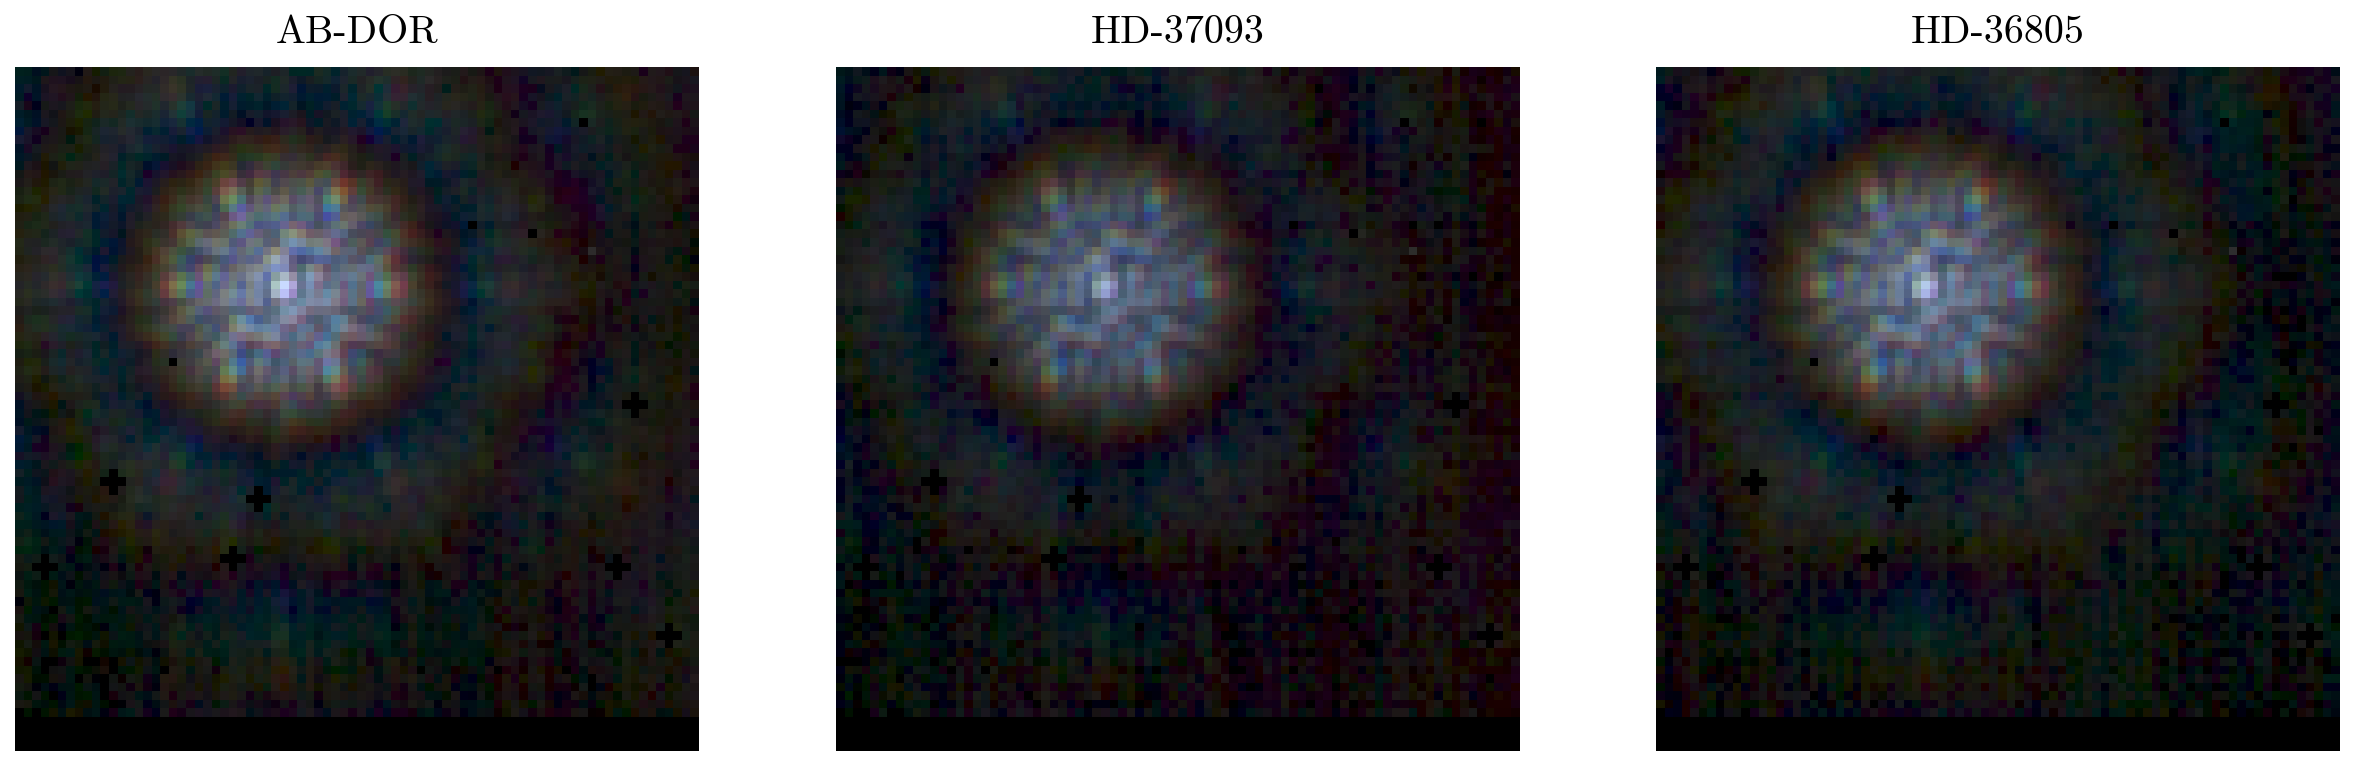

In [58]:
abdor = get_rgb("AB-DOR")
abdorcal1 = get_rgb("HD-37093")
abdorcal2 = get_rgb("HD-36805")


# for filt, ch in abdor.items():
#     # print(ch[0].header)


abdor_rgb = normalise_rgb(abdor, p=0.3)
abdorcal1_rgb = normalise_rgb(abdorcal1, p=0.3)
abdorcal2_rgb = normalise_rgb(abdorcal2, p=0.3)


fig, ax = plt.subplots(1, 3, figsize=(10, 3), dpi=300)

ax[0].imshow(abdor_rgb, origin="lower", interpolation="nearest")
ax[0].set(title="AB-DOR")
ax[0].axis("off")

ax[1].imshow(abdorcal1_rgb, origin="lower", interpolation="nearest")
ax[1].set(title="HD-37093")
ax[1].axis("off")

ax[2].imshow(abdorcal2_rgb, origin="lower", interpolation="nearest")
ax[2].set(title="HD-36805")
ax[2].axis("off")

plt.show()